# Langgraph with Tools

In [ ]:
!pip install langgraph langsmith langchain langchain_groq langchain_community

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict

# Working with tools with langgraph

A Tool in LangChain is a function or capability that an LLM can use to perform actions or retrieve information from outside itself.

Without tools, an LLM can only generate text based on what it already knows.

With tools, it can:

* Search the internet
* Read Wikipedia
* Search research papers
* Execute Python code
* Query databases
* Call APIs
* Perform calculations
* Read PDFs
* Search vector databases
* and much more.


## Arxiv and Wekipedia LangChain Tools

### Arxiv Tool :
The Arxiv Tool searches research papers from arXiv.

The LangChain arXiv tool allows LLM agents to query the arXiv.org repository to search, retrieve, and summarize scientific research papers.


### Wikipedia Tool :
The Wikipedia Tool allows the LLM to search and retrieve information from Wikipedia.

Instead of relying only on its training data, it queries Wikipedia in real time.


In [ ]:
!pip install arxiv wikipedia

In [ ]:
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun

### Axriv and Wikipedia Tools
arxiv_wrapper=ArxivAPIWrapper(top_k_results=1, doc_content_chars_max=300)
arxiv_tool=ArxivQueryRun(api_wrapper=arxiv_wrapper)

wikipedia_wrapper=WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=300)
wikipedia_tool=WikipediaQueryRun(api_wrapper=wikipedia_wrapper)


In [ ]:
# Wkipedia_tool example
wikipedia_tool.invoke("Who is Donald Trump?")

'Page: Trump family\nSummary: The Trump family is a prominent wealthy American family. The best-known member is patriarch Donald Trump, the 45th and current 47th president of the United States (2017–2021, 2025–present). \nThe Trumps are of German descent. They are active in business, entertainment, pol'

In [ ]:
# Arxiv_tool example
import arxiv
import types

# 1. DEFINE THE MONKEYPATCH FIX
# This replaces LangChain's broken internal '_fetch_results' method
# with one that securely calls the native client layout.
def fixed_fetch_results(self, query: str):
    client = arxiv.Client()
    search = self.arxiv_search(
        query[: self.ARXIV_MAX_QUERY_LENGTH],
        max_results=self.top_k_results
    )
    return client.results(search)

# 2. APPLY THE PATCH
# We bind our fix directly onto the imported ArxivAPIWrapper class
ArxivAPIWrapper._fetch_results = fixed_fetch_results

# ====================================================
# 3. RUN YOUR ORIGINAL CODE
# ====================================================

# Initialize the tool
arxiv_wrapper = ArxivAPIWrapper(top_k_results=3)
arxiv_tool = ArxivQueryRun(api_wrapper=arxiv_wrapper)

# Run your query safely
result = arxiv_tool.invoke("Retrieval-Augmented Generation")
print(result)


Published: 2025-06-14
Title: AR-RAG: Autoregressive Retrieval Augmentation for Image Generation
Authors: Jingyuan Qi, Zhiyang Xu, Qifan Wang, Lifu Huang
Summary: We introduce Autoregressive Retrieval Augmentation (AR-RAG), a novel paradigm that enhances image generation by autoregressively incorporating knearest neighbor retrievals at the patch level. Unlike prior methods that perform a single, static retrieval before generation and condition the entire generation on fixed reference images, AR-RAG performs context-aware retrievals at each generation step, using prior-generated patches as queries to retrieve and incorporate the most relevant patch-level visual references, enabling the model to respond to evolving generation needs while avoiding limitations (e.g., over-copying, stylistic bias, etc.) prevalent in existing methods. To realize AR-RAG, we propose two parallel frameworks: (1) Distribution-Augmentation in Decoding (DAiD), a training-free plug-and-use decoding strategy that dir

In [ ]:
tools=[wikipedia_tool]

In [ ]:
## Langgraph Application
from langgraph.graph.message import add_messages
class State(TypedDict):
  messages:Annotated[list,add_messages]

In [ ]:
from langgraph.graph import StateGraph,START,END

In [ ]:
graph_builder= StateGraph(State)

In [ ]:
from langchain_groq import ChatGroq

In [ ]:
from google.colab import userdata
groq_api_key=userdata.get("GROQ_API_KEY")

In [ ]:
llm=ChatGroq(groq_api_key=groq_api_key,model_name="llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.13'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x7fa3ffe46bd0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7fa3ffd340b0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [ ]:
llm_with_tools=llm.bind_tools(tools=tools)

In [ ]:
def chatbot(state:State):
  return {"messages":[llm_with_tools.invoke(state["messages"])]}

In [ ]:
from langgraph.prebuilt import ToolNode,tools_condition

In [ ]:
graph_builder.add_node("chatbot",chatbot)
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START,"chatbot")

In [ ]:
graph=graph_builder.compile()

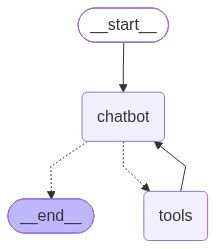

In [ ]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
user_input="Hi there!, My name is John"

events=graph.stream(
     {"messages": [("user", user_input)]},stream_mode="values"
)

for event in events:
  event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi there!, My name is John
================================== Ai Message ==================================

It's nice to meet you, John. Is there something I can help you with?


In [ ]:
user_input = "what is RLHF."

# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [("user", user_input)]},stream_mode="values"
)

for event in events:
  event['messages'][-1].pretty_print()

================================ Human Message =================================

what is RLHF.
================================== Ai Message ==================================
Tool Calls:
  wikipedia (rjb1mjd16)
 Call ID: rjb1mjd16
  Args:
    query: RLHF
================================= Tool Message =================================
Name: wikipedia

Page: Reinforcement learning from human feedback
Summary: In machine learning, reinforcement learning from human feedback (RLHF) is a technique to align an intelligent agent with human preferences. It involves training a reward model to represent preferences, which can then be used to train other mo
================================== Ai Message ==================================
Tool Calls:
  wikipedia (x0tfb87tj)
 Call ID: x0tfb87tj
  Args:
    query: RLHF reinforcement learning
================================= Tool Message =================================
Name: wikipedia

Page: Reinforcement learning from human feedback
Summary: In m